# 📚 Student Performance Factors Analysis with Python

This notebook is part of the studentperformance project, whose goal is to explore which factors impact the most in a student score.

In this study we dive into some factors like:

- Hours Studied
- Attendance on classes
- Parental Involvement
- Acess to Resources
- Sleep Hours
- And many others!

The goal is to provide an analytical view over the key factors that holds most influence under an Student Performance on a exam.



#### 1. Setup and Data Loading

In [15]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/StudentPerformanceFactors.csv')

display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

#### 2. Data Cleaning

Before starting an exploratory analysis, we need to ensure data quality, so we're going to check:
- Existence of null values ​​(NaN).

- Duplicate data.

- Incorrect data types.

In [17]:
#Checking the number of null values ​​per column
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

#### Handling Null Values


We identified null values in the columns: `Teacher_Quality`, `Parental_Education_Level` and `Distance_from_Home`.

**Strategy Adopted:**
Since all are categorical variables, we will opt for imputation by mode (filling in with the most frequent value). This preserves the statistical distribution of the data without introducing bias from new categories.

In [18]:
cols_with_missing = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in cols_with_missing:
    mode_value = df[col].mode()[0] 
    df[col].fillna(mode_value, inplace=True)
    print(f"Null values in '{col}' filled with: {mode_value}")

print("\nNulls remaining:", df.isnull().sum().sum())

duplicates = df.duplicated().sum()
print(f"Duplicated rows: {duplicates}")

Null values in 'Teacher_Quality' filled with: Medium
Null values in 'Parental_Education_Level' filled with: High School
Null values in 'Distance_from_Home' filled with: Near

Nulls remaining: 0
Duplicated rows: 0


/tmp/ipykernel_2180/2793709858.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


### 3. Correlation Analysis

Let's understand how numerical variables relate to each other.

The goal here is to see which factors have the highest correlation (positive or negative) with the final grade (`Exam_Score`).

* **Positive Correlation (close to 1):** When one increases, the other also increases (Ex: Study hours vs. Grade).

* **Negative Correlation (close to -1):** When one increases, the other decreases (Ex: Absences vs. Grade).

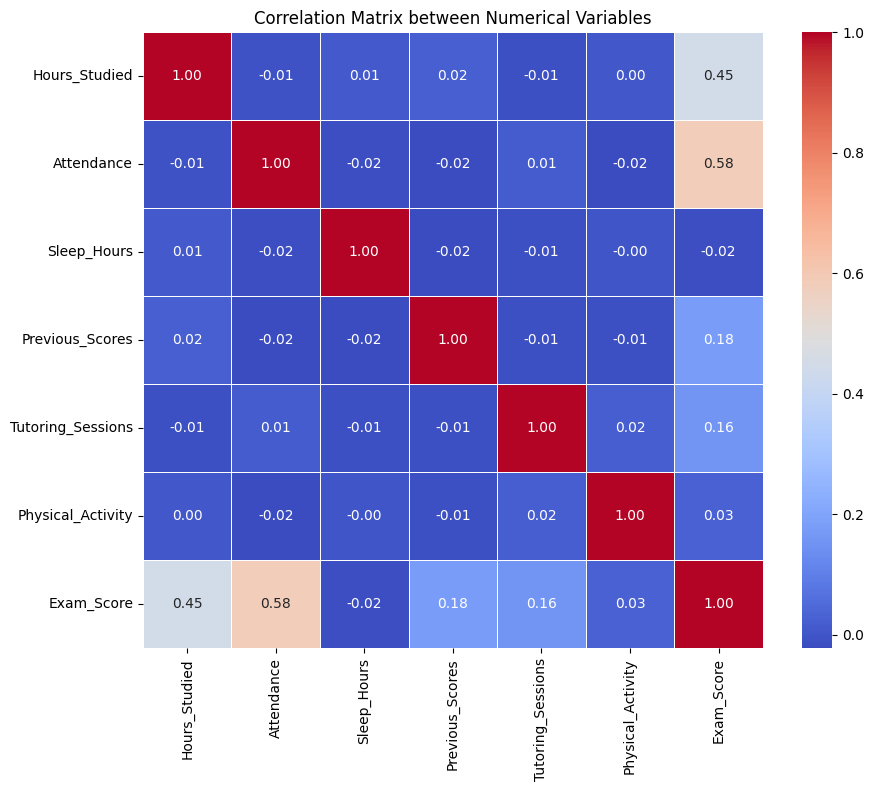

In [19]:
#For a correlation matrix, we can only use numerical variables. So we need to create a dataframe with only numerical columns.
df_numeric = df.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix between Numerical Variables')
plt.show()

#### 💡 Insights from the Correlation Matrix

Analyzing the relationship between the numerical variables and the target variable (`Exam_Score`), the following stand out:

1. **Attendance is Fundamental (`Attendance`: 0.58):** The variable with the greatest positive impact on the final grade. This suggests that classroom attendance is the most critical determinant of student success.

2. **Hours of Study (`Hours_Studied`: 0.45):** Also shows a strong positive correlation. Students who dedicate more hours outside of class tend to have higher grades.

3. **Reduced Impact of the Past (`Previous_Scores`: 0.18):** Surprisingly, previous grades have a weak correlation. This indicates that current performance depends more on immediate effort (attendance and study) than on academic history. 

4. **Neutral Factors:** Sleep and Physical Activity showed a correlation close to zero, indicating that, in isolation, they do not linearly determine the final grade.

### Scatter Plots

Now that the Heatmap has told us that Attendance and Hours_Studied are the "bosses", let's visualize this in detail.

Let's create the Scatterplots:

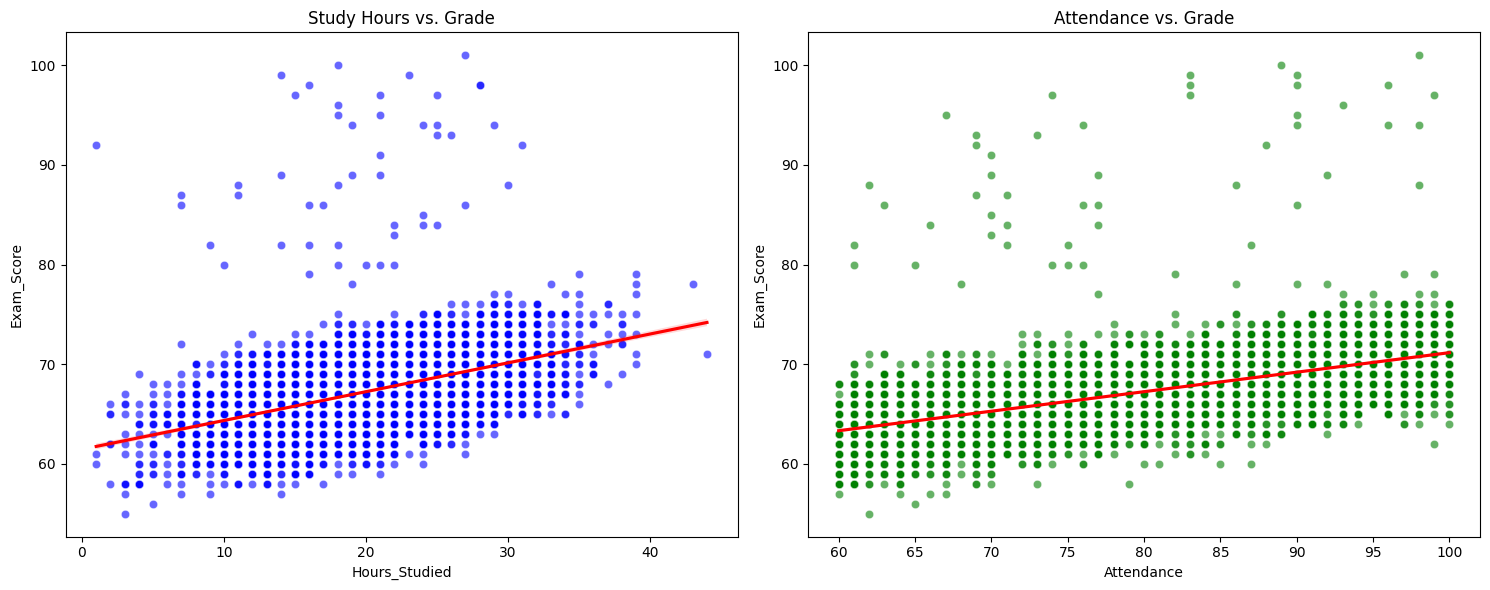

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

#Chart 1: Study Hours vs. Grade
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', ax=ax[0], color='blue', alpha=0.6)
sns.regplot(data=df, x='Hours_Studied', y='Exam_Score', ax=ax[0], scatter=False, color='red')
ax[0].set_title('Study Hours vs. Grade')

#Chart 2: Attendance vs. Grade
sns.scatterplot(data=df, x='Attendance', y='Exam_Score', ax=ax[1], color='green', alpha=0.6)
sns.regplot(data=df, x='Attendance', y='Exam_Score', ax=ax[1], scatter=False, color='red')
ax[1].set_title('Attendance vs. Grade')

plt.tight_layout()
plt.show()

### 4. Analyzing Social & External Factors

We established that study habits (Attendance and Hours Studied) are crucial. Now, let's investigate if the student's environment and background play a significant role.

**Questions:**
* Does having access to **resources** or the **internet** provide an advantage?
* Does **parental involvement** correlate with higher scores?

/tmp/ipykernel_2180/2943794071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Access_to_Resources', y='Exam_Score', ax=ax[0], palette='Set2')
/tmp/ipykernel_2180/2943794071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', ax=ax[1], palette='Set2')
/tmp/ipykernel_2180/2943794071.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Internet_Access', y='Exam_Score', ax=ax[2], palette='Set2')


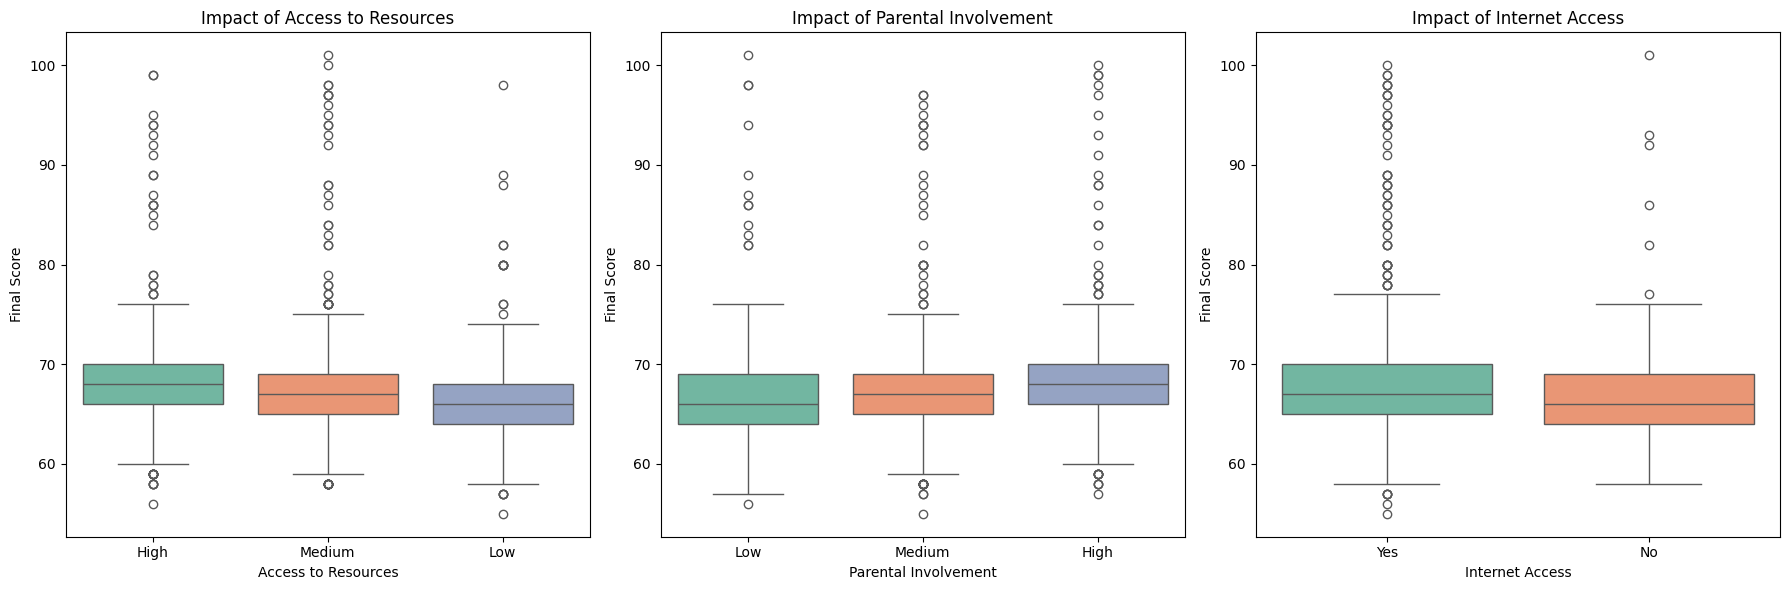

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

#Plot 1: Access to Resources vs Exam Score
sns.boxplot(data=df, x='Access_to_Resources', y='Exam_Score', ax=ax[0], palette='Set2')
ax[0].set_title('Impact of Access to Resources')
ax[0].set_xlabel('Access to Resources')
ax[0].set_ylabel('Final Score')

#Plot 2: Parental Involvement vs Exam Score
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', ax=ax[1], palette='Set2')
ax[1].set_title('Impact of Parental Involvement')
ax[1].set_xlabel('Parental Involvement')
ax[1].set_ylabel('Final Score')

#Plot 3: Internet Access vs Exam Score
sns.boxplot(data=df, x='Internet_Access', y='Exam_Score', ax=ax[2], palette='Set2')
ax[2].set_title('Impact of Internet Access')
ax[2].set_xlabel('Internet Access')
ax[2].set_ylabel('Final Score')

plt.tight_layout()
plt.show()

#### 💡 Insights on Social Factors

Contrary to common assumptions, the boxplots reveal that external/social factors have a **limited impact** on the final score compared to study habits.

1.  **Access to Resources:** The median scores for students with `High`, `Medium`, and `Low` access to resources are remarkably similar. While the `High` group has slightly fewer low-scoring outliers, the overall performance distribution is nearly identical across groups.
2.  **Parental Involvement:** Higher parental involvement shows a marginal increase in the median score and a tighter distribution (less variation), but it is not a decisive factor for high performance.
3.  **Internet Access:** The difference between students with and without internet access is negligible.

**Conclusion:**
In this dataset, academic success appears to be driven more by individual habits (Attendance, Study Hours) than by socioeconomic background or external resources. This suggests a scenario where student effort is the primary differentiator.

### 5. Target Variable Analysis (Exam Score)

Finally, let's look at the distribution of the target variable itself.

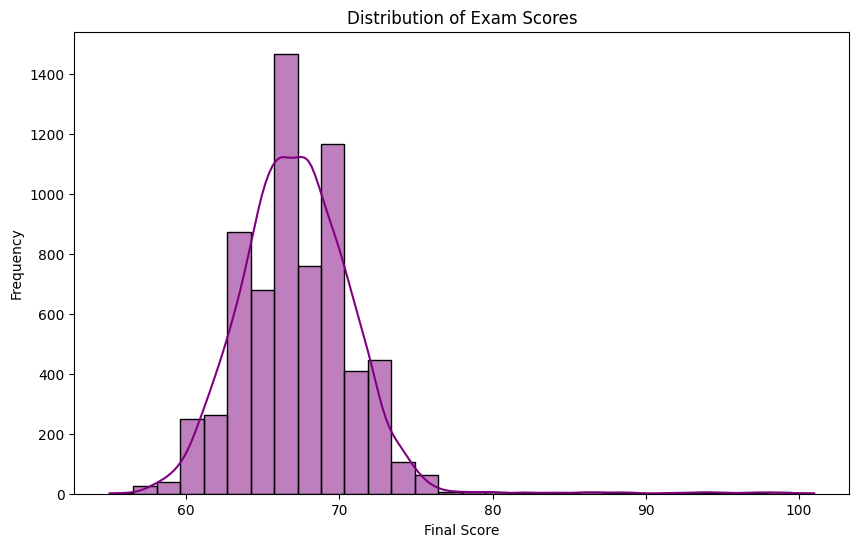

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], kde=True, bins=30, color='purple')
plt.title('Distribution of Exam Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

#### 💡 Insights on Target Variable (Exam Score)

The histogram reveals a distribution that closely resembles a Normal Distribution (Bell Curve), centered around a mean of approximately 67-68.

* **Central Tendency:** Most students score between 65 and 70.
* **Skewness:** There is a slight positive skew (long tail to the right), indicating that while the average is moderate, achieving very high scores (>90) is rare and represents outlier behavior.
* **Modeling Suitability:** This "near-normal" distribution is ideal for training Linear Regression models, as it satisfies the assumption of normality for the target variable.

## 🤖 Machine Learning! :D

Now that we have completed the full analysis cycle: cleaning, correlation, and visualization of the most impactful factors on a Student Perfomance in this dataset, we're going to create a model that predicts the grade of a new student.

#### Data Preprocessing for Machine Learning

Before training a model, we must convert categorical variables (text) into numerical format.
We will use Label Encoding for ordinal variables (Low/Medium/High) and One-Hot Encoding for nominal variables (Yes/No).

In [ ]:
#Separating the features (X) and the target (y)
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

#Converting categorical variables to numbers (One-Hot Encoding)
#Adding 'dtype=int' to force True/False to become 1/0
X = pd.get_dummies(X, drop_first=True, dtype=int)

#Checking the new shape of the data
print(f"Original shape: {df.shape}")
print(f"New shape for ML: {X.shape}")
X.head()

Original shape: (6607, 20)
New shape for ML: (6607, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,1,0,0,0,...,1,1,0,1,0,1,0,0,1,1
1,19,64,8,59,2,4,1,0,0,1,...,1,1,0,0,0,0,0,1,0,0
2,24,98,7,91,2,4,0,1,0,1,...,1,1,1,0,0,0,1,0,1,1
3,29,89,8,98,1,4,1,0,0,1,...,1,1,0,0,0,1,0,1,0,1
4,19,92,6,65,3,4,0,1,0,1,...,0,1,1,0,0,0,0,0,1,0


#### Model Training (Linear Regression)

We will split the data into training (80%) and testing (20%) sets to evaluate the model's performance on unseen data.
We chose Linear Regression as our baseline model because of its interpretability and the linear nature of the relationships observed in the EDA.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

#Splitting the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initializing the Model
model = LinearRegression()

#Training the Model (Fitting)
model.fit(X_train, y_train)

#Making Predictions on the Test Set
y_pred = model.predict(X_test)

#Evaluating the Model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

R² Score (Accuracy): 0.7696
Mean Absolute Error (MAE): 0.45


#### Model Visualization: Actual vs. Predicted

To visualize the accuracy of our model, we plot the Actual Values (y_test) against the Predicted Values (y_pred).
Ideally, all points should lie on the red diagonal line (Perfect Prediction).

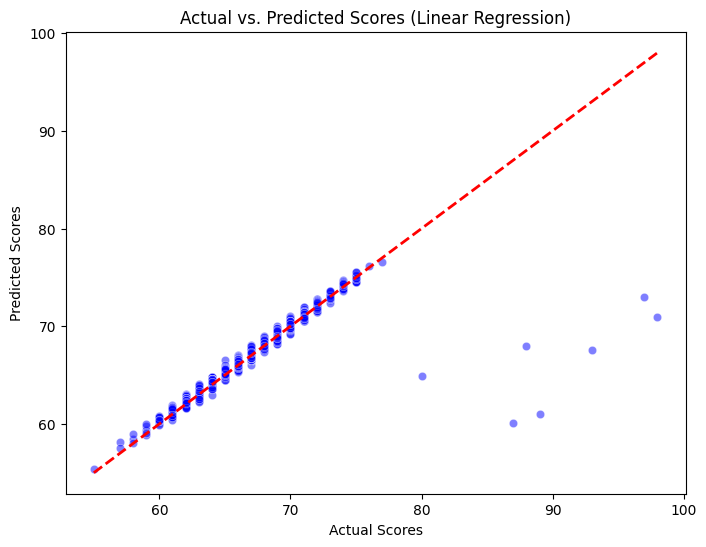

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.5)

#Creating a red line representing perfect prediction
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs. Predicted Scores (Linear Regression)')
plt.show()

## Model Performance Analysis & Conclusion

To conclude our study, we evaluated the performance of the Linear Regression model using statistical metrics and visual inspection.

#### 📊 Key Metrics Results
* **$R^2$ Score (0.77):** The model explains approximately **77% of the variance** in the final exam scores. This is a high value for behavioral data, confirming that our selected features (especially *Attendance* and *Hours Studied*) are highly effective predictors.
* **Mean Absolute Error (MAE: 0.45):** On average, the model's prediction deviates from the actual score by less than **0.5 points**. Considering the scale of exam scores (0-100), this indicates high precision.

#### 🔎 Visual Interpretation (Actual vs. Predicted)
The scatter plot above confirms the model's robustness:
1.  **Linearity:** The vast majority of data points follow the red diagonal line, showing a strong linear relationship between predicted and actual values.
2.  **Consistency:** The model performs well across the entire range of scores (from low to high grades), without showing significant bias towards one specific group.
3.  **Outliers:** There are a few isolated cases where the model underestimated or overestimated the score, which is expected in human-centric data (factors like "test anxiety" or "luck" cannot be measured by the dataset).

#### 🚀 Final Verdict
The project successfully demonstrated that student performance is largely predictable based on measurable habits. **Class attendance** and **study time** proved to be the most critical factors, outweighing socioeconomic variables like internet access or family income in this specific dataset.